In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

In [ ]:
# Read CSV into DataFrame
df = pd.read_csv('IRIS.csv')

In [ ]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [ ]:
print("\nShape:", df.shape)


Shape: (150, 5)


In [ ]:
print("\n=== Data Info ===")
df.info()


=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
print("\n=== Descriptive Statistics (numeric) ===")
print(df.describe(include=[np.number]))


=== Descriptive Statistics (numeric) ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [ ]:
print("\n=== Missing Values By Column ===")
print(df.isna().sum())


=== Missing Values By Column ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [ ]:
# Basic class balance overview
if 'species' in df.columns:
    print("\n=== Class Balance (species) ===")
    print(df['species'].value_counts())


=== Class Balance (species) ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# Detect numeric columns for quick plotting
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

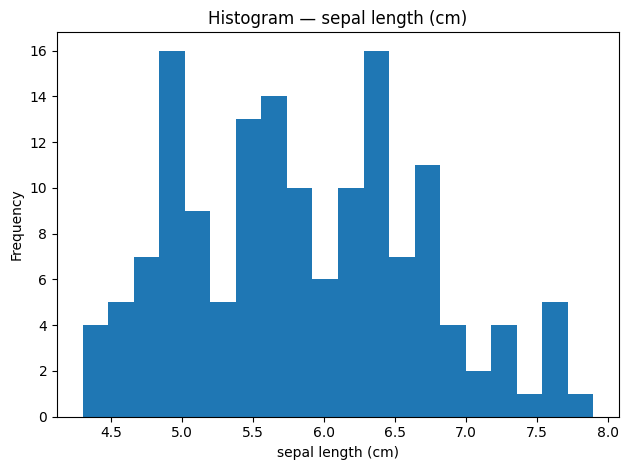

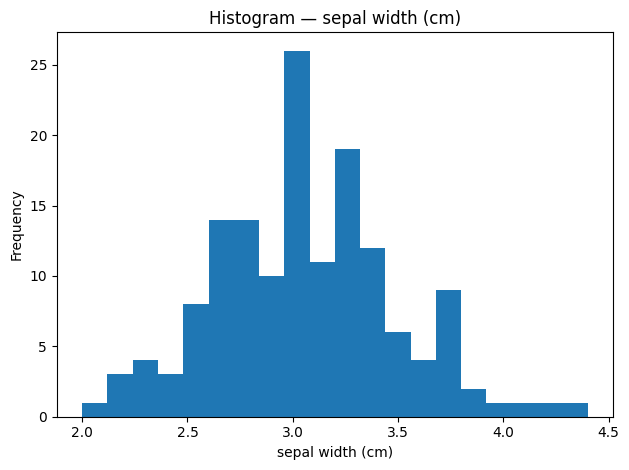

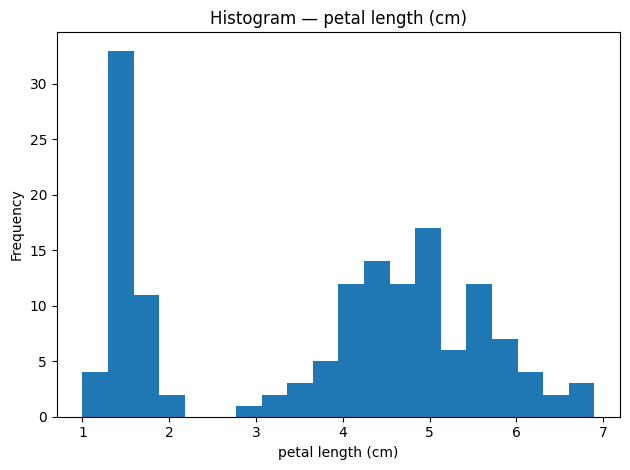

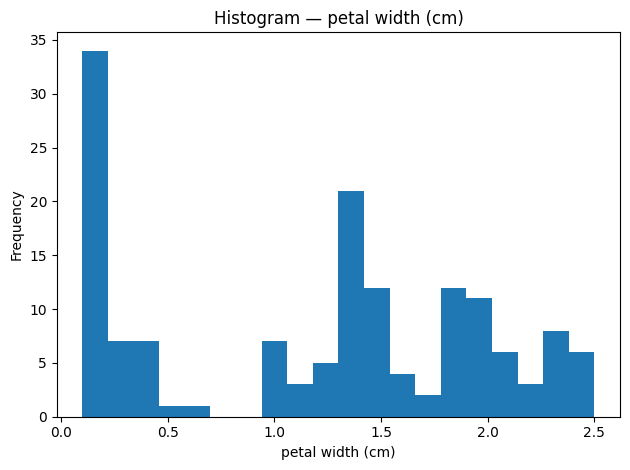

In [ ]:
# (a) Histograms for each numeric feature
for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram — {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

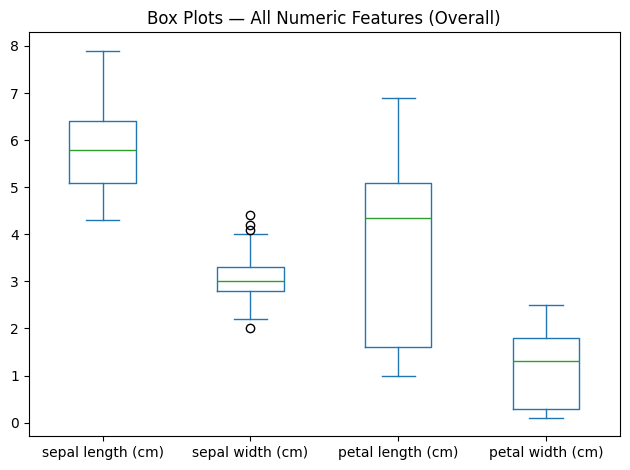

In [ ]:
# (b) Box plots (overall)
plt.figure()
df[num_cols].plot(kind='box')
plt.title("Box Plots — All Numeric Features (Overall)")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

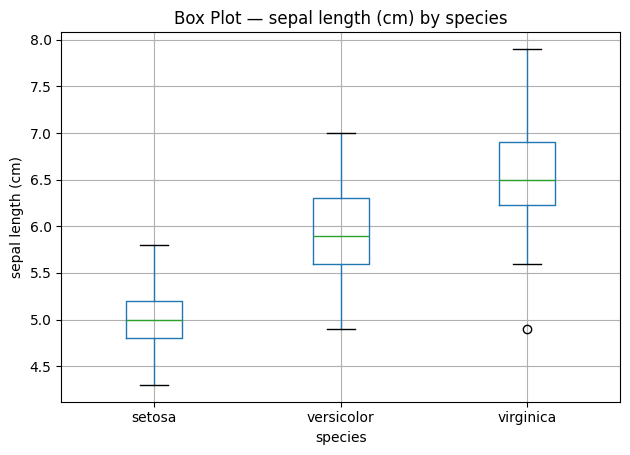

<Figure size 640x480 with 0 Axes>

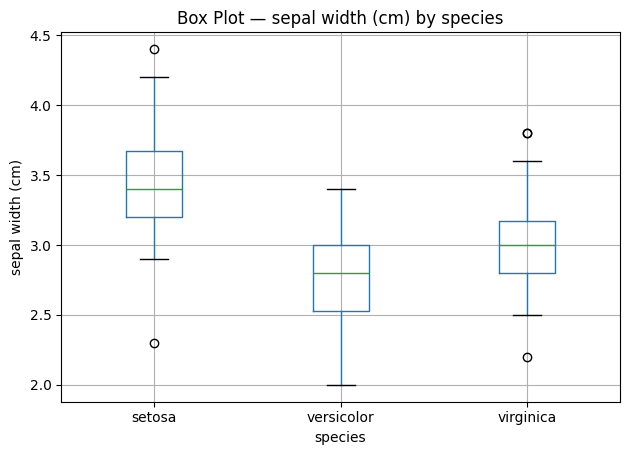

<Figure size 640x480 with 0 Axes>

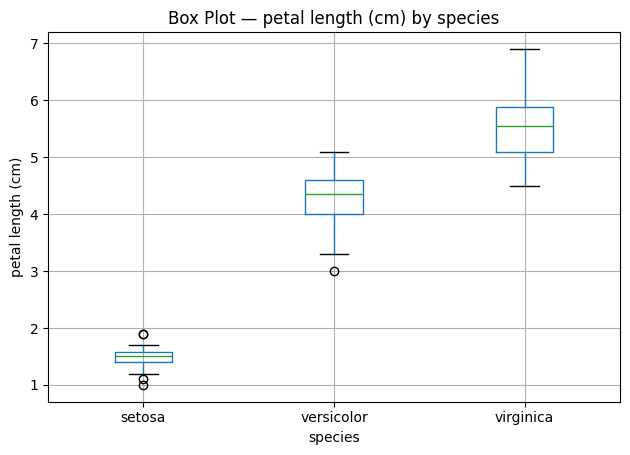

<Figure size 640x480 with 0 Axes>

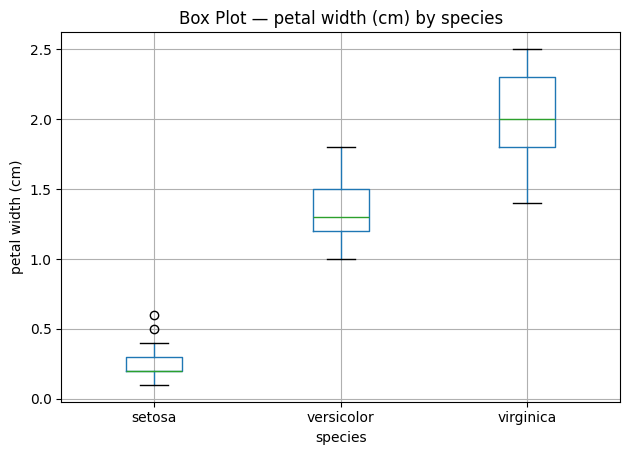

In [ ]:
# (c) Box plots by class (if species exists)
if 'species' in df.columns:
    for col in num_cols:
        plt.figure()
        df.boxplot(column=col, by='species')
        plt.title(f"Box Plot — {col} by species")
        plt.suptitle("")
        plt.xlabel("species")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


<Figure size 640x480 with 0 Axes>

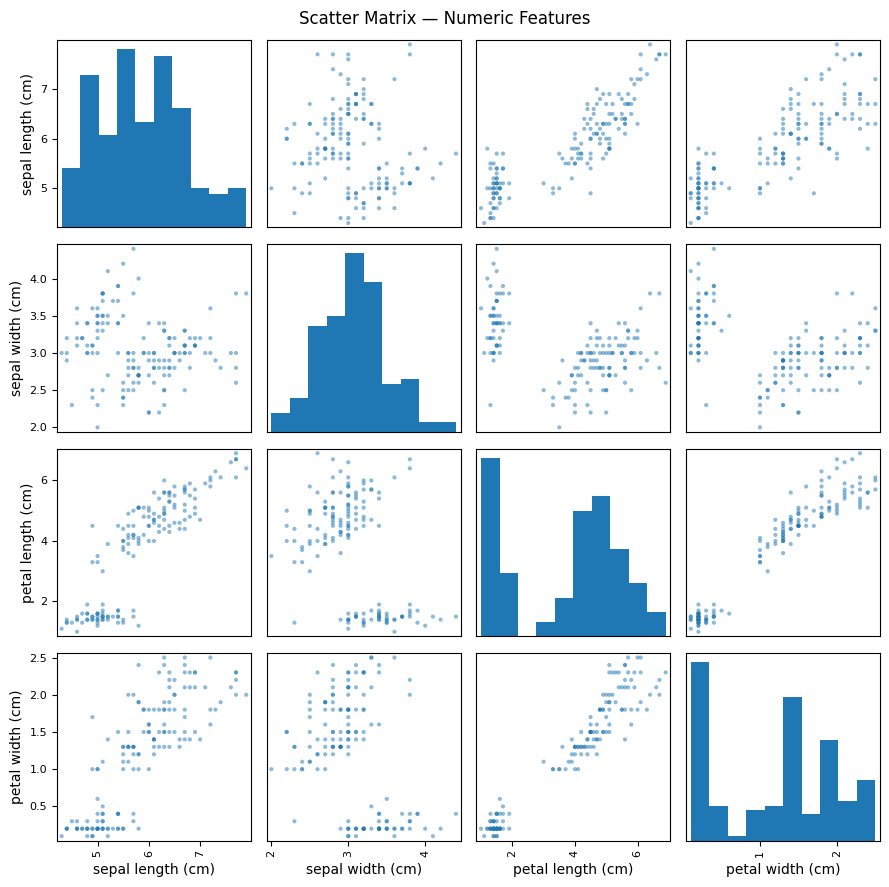

In [ ]:
# (d) Scatter matrix to visualize pairwise relationships
if len(num_cols) >= 2:
    plt.figure()
    scatter_matrix(df[num_cols], diagonal='hist', figsize=(9, 9))
    plt.suptitle("Scatter Matrix — Numeric Features")
    plt.tight_layout()
    plt.show()

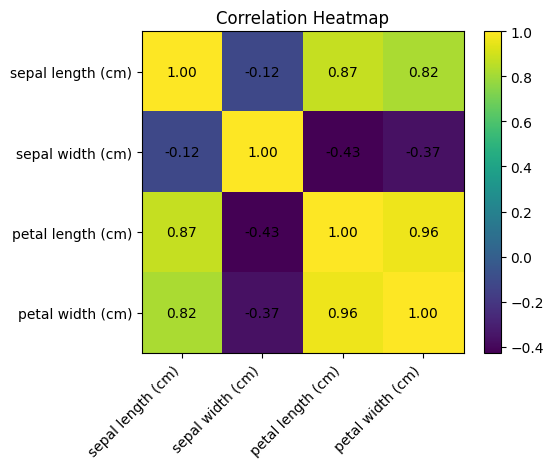

In [ ]:
#Simple correlation heatmap (no seaborn)
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure()
    im = plt.imshow(corr.values, interpolation='nearest')
    plt.title("Correlation Heatmap")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
    plt.yticks(range(len(num_cols)), num_cols)
    # Annotate the correlation values
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            plt.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center')
    plt.tight_layout()
    plt.show()

In [ ]:
assert 'species' in df.columns, "Expected a 'species' column in the dataset."

# Select features (all numeric cols) and label
X = df[num_cols].copy()
y_raw = df['species'].astype(str).copy()

# Impute numeric missing values with median
X = X.fillna(X.median(numeric_only=True))

# Drop rows with missing labels if any
valid_label_mask = y_raw.notna()
X = X.loc[valid_label_mask].reset_index(drop=True)
y_raw = y_raw.loc[valid_label_mask].reset_index(drop=True)

# Encode string labels to integers
classes = sorted(y_raw.unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
y = y_raw.map(class_to_idx).astype(int).values  # shape (N,)

# Standardize features: z = (x - mean)/std  (computed on the whole dataset before split for simplicity)
X_mean = X.mean(axis=0).values
X_std = X.std(axis=0, ddof=0).replace(0, 1).values  # avoid divide-by-zero
X_stdized = (X.values - X_mean) / X_std

In [ ]:
# Convert to numpy arrays
X = X_stdized.astype(float)
N, D = X.shape
C = len(classes)
print(f"\nPreprocessed shapes — X: {X.shape}, y: {y.shape}, #classes: {C}")
print("Classes:", {i: cls for i, cls in enumerate(classes)})


Preprocessed shapes — X: (150, 4), y: (150,), #classes: 3
Classes: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


In [ ]:
# ======================================
# 6) Train/Test Split (manual, stratified)
# ======================================
# We'll do an 80/20 split with simple stratification per class to preserve balance.
TEST_SIZE = 0.2
rng = np.random.default_rng(42)

train_indices = []
test_indices = []
for k in range(C):
    idx_k = np.where(y == k)[0]
    rng.shuffle(idx_k)
    n_test_k = max(1, int(len(idx_k) * TEST_SIZE))
    test_indices.extend(idx_k[:n_test_k].tolist())
    train_indices.extend(idx_k[n_test_k:].tolist())

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

print(f"Train size: {len(train_indices)}, Test size: {len(test_indices)}")

Train size: 120, Test size: 30


In [ ]:
# ======================================
# 7) Multiclass Logistic Regression (Softmax) — From Scratch
# ======================================
# Model: P(y=k|x) = softmax(Wx + b)
# Loss: Cross-entropy + L2 regularization
# Optimization: Batch Gradient Descent

# Helper: one-hot encoding
def to_one_hot(y_int, num_classes):
    """Convert integer labels to one-hot matrix."""
    oh = np.zeros((y_int.shape[0], num_classes), dtype=float)
    oh[np.arange(y_int.shape[0]), y_int] = 1.0
    return oh

In [ ]:
# Helper: softmax (stable)
def softmax(z):
    """Compute row-wise softmax for a 2D array with numeric stability."""
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
# Compute loss and gradients
def compute_loss_and_grads(W, b, Xb, yb_onehot, l2):
    """
    Compute cross-entropy loss with L2 and gradients for W, b.
    W: (D, C), b: (C,)
    Xb: (B, D), yb_onehot: (B, C)
    """
    B = Xb.shape[0]
    logits = Xb @ W + b  # (B, C)
    probs = softmax(logits)  # (B, C)
    # Cross-entropy loss
    eps = 1e-12
    ce = -np.sum(yb_onehot * np.log(probs + eps)) / B
    # L2 regularization (exclude bias)
    l2_term = 0.5 * l2 * np.sum(W * W)
    loss = ce + l2_term

    # Gradients
    dlogits = (probs - yb_onehot) / B  # (B, C)
    dW = Xb.T @ dlogits + l2 * W       # (D, C)
    db = np.sum(dlogits, axis=0)       # (C,)
    return loss, dW, db

In [ ]:
# Training loop
def train_softmax_regression(X_train, y_train, X_val, y_val, C, epochs=800, lr=0.1, l2=1e-3, verbose=True):
    """Train softmax regression via batch gradient descent."""
    N, D = X_train.shape
    W = np.zeros((D, C), dtype=float)
    b = np.zeros((C,), dtype=float)

    y_train_oh = to_one_hot(y_train, C)
    y_val_oh = to_one_hot(y_val, C)

    history = {"epoch": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        # Compute loss and gradients on train
        loss, dW, db = compute_loss_and_grads(W, b, X_train, y_train_oh, l2)
        # Parameter update
        W -= lr * dW
        b -= lr * db

        # Optionally track validation loss
        with np.errstate(over='ignore', invalid='ignore'):
            val_loss, _, _ = compute_loss_and_grads(W, b, X_val, y_val_oh, l2)

        # Save history
        if epoch % 10 == 0 or epoch == 1:
            history["epoch"].append(epoch)
            history["train_loss"].append(loss)
            history["val_loss"].append(val_loss)
            if verbose and (epoch % 100 == 0 or epoch == 1):
                print(f"Epoch {epoch:4d} | train_loss={loss:.4f} | val_loss={val_loss:.4f}")

    return W, b, history

In [ ]:
# Predict class indices
def predict_classes(W, b, Xb):
    logits = Xb @ W + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1), probs


In [ ]:
# Train the model (use a portion of train as validation for monitoring)
# We'll carve 10% of train as validation
n_train = X_train.shape[0]
val_count = max(1, int(0.1 * n_train))
val_idx = train_indices[:val_count]  # reuse original ordering slice for simplicity
train_core_idx = train_indices[val_count:]

X_tr_core = X[train_core_idx]
y_tr_core = y[train_core_idx]
X_val = X[val_idx]
y_val = y[val_idx]

W, b, history = train_softmax_regression(
    X_tr_core, y_tr_core, X_val, y_val,
    C=C, epochs=800, lr=0.1, l2=1e-3, verbose=True
)

Epoch    1 | train_loss=1.0986 | val_loss=0.9652
Epoch  100 | train_loss=0.3488 | val_loss=0.0789
Epoch  200 | train_loss=0.2788 | val_loss=0.0570
Epoch  300 | train_loss=0.2391 | val_loss=0.0500
Epoch  400 | train_loss=0.2129 | val_loss=0.0464
Epoch  500 | train_loss=0.1945 | val_loss=0.0442
Epoch  600 | train_loss=0.1809 | val_loss=0.0426
Epoch  700 | train_loss=0.1705 | val_loss=0.0414
Epoch  800 | train_loss=0.1623 | val_loss=0.0405


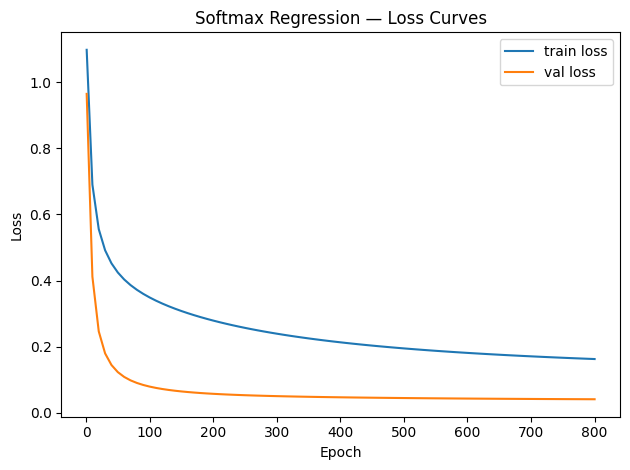

In [ ]:
# Plot training vs validation loss history
if len(history["epoch"]) > 0:
    plt.figure()
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.title("Softmax Regression — Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ======================================
# 8) Evaluation — Accuracy, Confusion Matrix, TP/FP/TN/FN, Precision, F1
# ======================================
# Predict on test set
y_pred, y_proba = predict_classes(W, b, X_test)

# Confusion Matrix (C x C)
cm = np.zeros((C, C), dtype=int)
for t, p in zip(y_test, y_pred):
    cm[t, p] += 1

# Compute accuracy
accuracy = np.sum(np.diag(cm)) / np.sum(cm) if np.sum(cm) > 0 else 0.0

# Per-class TP/FP/FN/TN
TP = np.diag(cm).astype(int)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)


=== Evaluation on Test Set ===
Accuracy: 1.0000

Per-class metrics (label -> class name):
Class 0 -> setosa: TP=10, FP=0, TN=20, FN=0, Precision=1.000, Recall=1.000, F1=1.000
Class 1 -> versicolor: TP=10, FP=0, TN=20, FN=0, Precision=1.000, Recall=1.000, F1=1.000
Class 2 -> virginica: TP=10, FP=0, TN=20, FN=0, Precision=1.000, Recall=1.000, F1=1.000

Macro-averaged:
Precision=1.000, Recall=1.000, F1=1.000


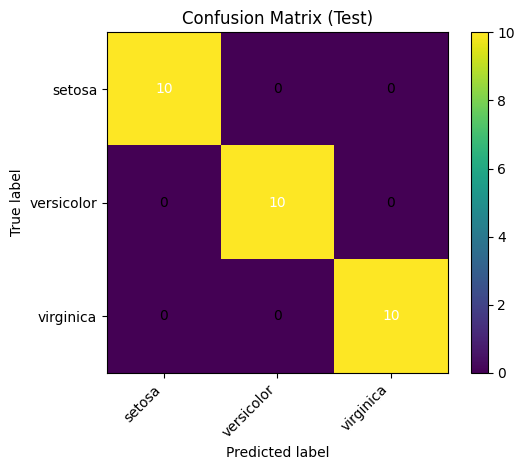

In [ ]:
# Per-class precision, recall, F1; macro averages
precision_per_class = np.where(TP + FP > 0, TP / (TP + FP), 0.0)
recall_per_class = np.where(TP + FN > 0, TP / (TP + FN), 0.0)
f1_per_class = np.where(
    precision_per_class + recall_per_class > 0,
    2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class),
    0.0,
)

macro_precision = precision_per_class.mean()
macro_recall = recall_per_class.mean()
macro_f1 = f1_per_class.mean()

# Print metrics in a tidy way
print("\n=== Evaluation on Test Set ===")
print(f"Accuracy: {accuracy:.4f}")
print("\nPer-class metrics (label -> class name):")
for i in range(C):
    print(f"Class {i} -> {idx_to_class[i]}: TP={TP[i]}, FP={FP[i]}, TN={TN[i]}, FN={FN[i]}, "
          f"Precision={precision_per_class[i]:.3f}, Recall={recall_per_class[i]:.3f}, F1={f1_per_class[i]:.3f}")

print("\nMacro-averaged:")
print(f"Precision={macro_precision:.3f}, Recall={macro_recall:.3f}, F1={macro_f1:.3f}")

# Plot Confusion Matrix with counts and accuracy
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Test)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(C), [idx_to_class[i] for i in range(C)], rotation=45, ha='right')
plt.yticks(range(C), [idx_to_class[i] for i in range(C)])

# Annotate counts
thresh = cm.max() / 2 if cm.max() > 0 else 0.5
for i in range(C):
    for j in range(C):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv('IRIS.csv') # DATA_PATH mentioned earlier
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values    # 3 classes: 0, 1, 2

classes, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(classes, counts)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-vs-Rest classifier
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=500))
ovr_model.fit(X_train, y_train)

# Predictions
y_pred = ovr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Class distribution: {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}
Accuracy: 0.9

Confusion Matrix:
 [[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



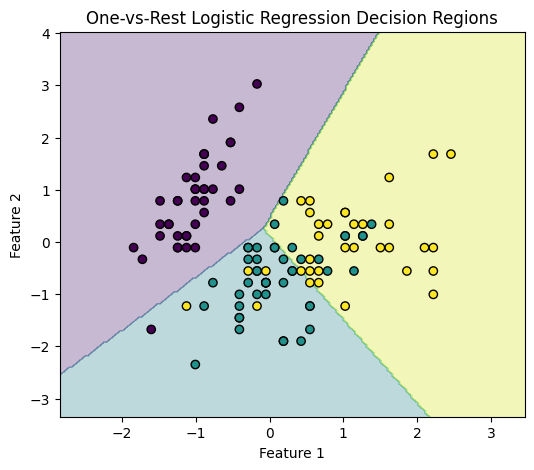

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("IRIS.csv")
X = data.iloc[:, :-1].values
y_raw = data.iloc[:, -1].values  # Strings

# 1. Encode string labels to integers (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Visualize using seleced 2 features only
X2 = X[:,[0, 1]] # (Change to see for other features)

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=500))
ovr_model.fit(X_train, y_train)

# Create meshgrid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = ovr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolors='k')
plt.title("One-vs-Rest Logistic Regression Decision Regions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Accuracy with 3 features: 0.8667


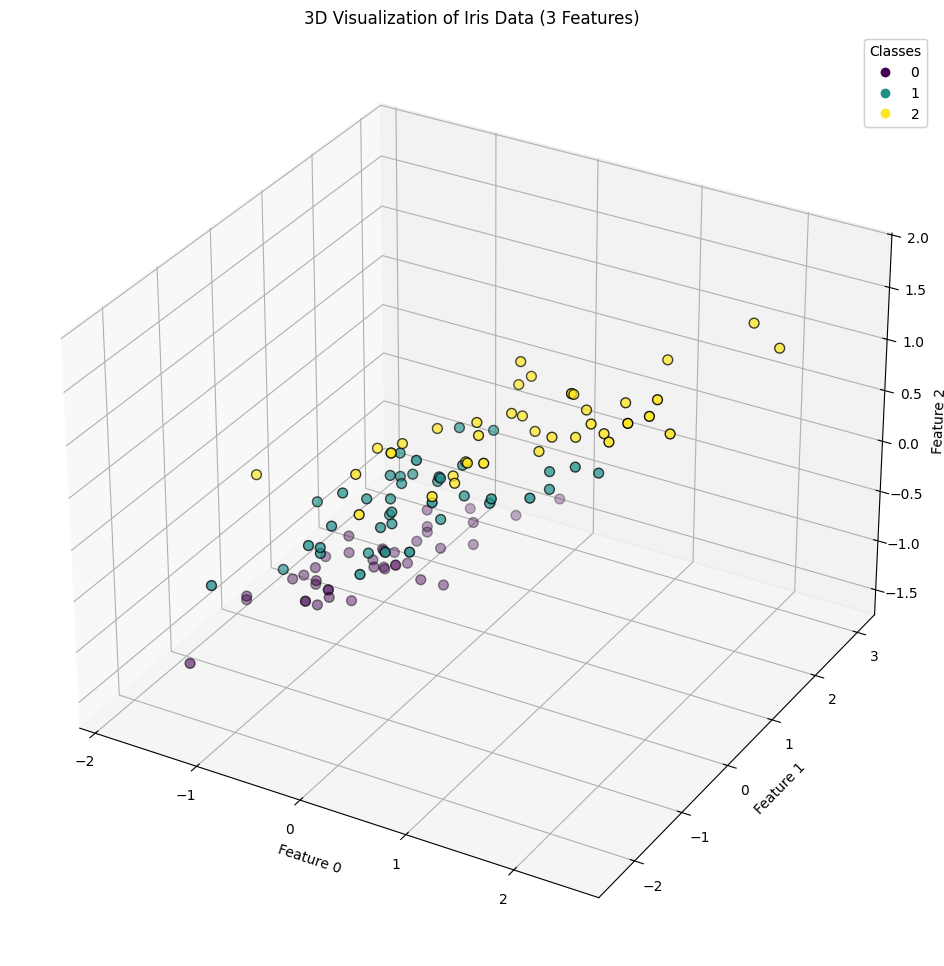

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

# Load dataset
data = pd.read_csv("IRIS.csv")
X = data.iloc[:, :-1].values
y_raw = data.iloc[:, -1].values

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)


# SELECT 3 FEATURES

# Let's use indices 0, 1, and 2 (Sepal Length, Sepal Width, Petal Length)
features_to_use = [0, 1, 2]
X3 = X[:, features_to_use]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model on 3 features
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=500))
ovr_model.fit(X_train, y_train)

# Check Accuracy
y_pred = ovr_model.predict(X_test)
print(f"Accuracy with 3 features: {accuracy_score(y_test, y_pred):.4f}")


# VISUALIZE IN 3D

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the training data
# c=y_train colors points by class
# cmap='viridis' is the color map
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2],
                     c=y_train, cmap='viridis', s=50, edgecolors='k')

# Add a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

ax.set_xlabel(f'Feature {features_to_use[0]}')
ax.set_ylabel(f'Feature {features_to_use[1]}')
ax.set_zlabel(f'Feature {features_to_use[2]}')
ax.set_title('3D Visualization of Iris Data (3 Features)')

plt.show()